# Mobile Game Product & Ad Monetization Analytics
- Understanding player engagement, advertising monetization, and long-term player value

### Core business question
> **How should a mobile game optimize in-app purchases and rewarded advertising to increase monetization and long-term player value without damaging player engagement and retention?**
>
Acquisition → Engagement → Ad exposure → Monetization → Retention → LTV

#### 1. Ad Monetization Funnel & Diagnostic Analysis
#### 2. Acquisition channel → retention/LTV

# 2. Ad Monetization Funnel & Diagnostic Analysis
### Business Question

> **Where are the biggest opportunities to improve advertising monetization across ad formats, placements, networks, platforms, and player cohorts?**
> 

The goal is to move beyond simply measuring ad impressions and identify **where monetization efficiency differs**.

### Hypothesis

- **H1:** (dropoff in active users -> ad exposed users) Ad exposure is the primary volume constraint. A meaningful share of active players generates limited or no ad impressions, suggesting that ad exposure/penetration is a larger constraint on total ad revenue than impression yield alone.

- **H2:** Advertising monetization efficiency varies meaningfully by **ad format/placement, network, platform, country, and player lifecycle stage**.

- **H3:** High impression volume does not necessarily translate into high revenue efficiency; some lower-volume inventory may generate disproportionately higher eCPM and revenue/user.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [12]:
df = pd.read_csv('/Users/asamitakeuchi/Downloads/Data/mobile-game-ltv-forecasting-challenge/train.csv')

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_1856/4108302586.py:1: DtypeWarning: Columns (10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/asamitakeuchi/Downloads/Data/mobile-game-ltv-forecasting-challenge/train.csv')


## Exploratory analysis

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21006238 entries, 0 to 21006237
Data columns (total 15 columns):
 #   Column             Dtype  
---  ------             -----  
 0   user_id            int64  
 1   platform           object 
 2   country_tier       object 
 3   channel_tier       object 
 4   install_day        int64  
 5   install_week       int64  
 6   day_since_install  int64  
 7   event_hour         int64  
 8   event_type         object 
 9   event_name         object 
 10  product_id         object 
 11  network            object 
 12  ad_placement       object 
 13  revenue_usd        float64
 14  ltv_d8_d180        float64
dtypes: float64(2), int64(5), object(8)
memory usage: 2.3+ GB


- **channel_tier**: Install media source. Channels with fewer than 50 users are grouped as other
- **install_day**: Days since the earliest install in the sample.
- **install_week**: install_day // 7
- **event_type**: Event category: session, iap (In-App Purchase), or ad_impression
- **event_name**: specific event: session_start, af_purchase / in_app_purchase, or ad format (ad_reward, ad_interstitial, etc.)
- - *Rewarded ads* are an opt-in advertising format where **users choose to watch a video, play a mini-game, or complete a survey in exchange for a tangible reward** within an app or website
- **product_id**: Purchased item ID (af_content_id for af_purchase, af_product_id otherwise). **Empty for non-IAP events.**
- **network**: Ad network name. Empty for non-ad events.
- - An advertising network is a technology business that connects companies wanting to display ads (advertisers) with website or app owners who have space available to show them.
- **ad_placement**: Ad placement name. Empty for non-ad events.
- - Ad placement is the specific location on a webpage, app, or social media platform where an advertisement appears
- **revenue_usd**: Revenue in USD for IAP or ad impression events. NaN for session events.

In [15]:
df.head()

,user_id,platform,country_tier,channel_tier,install_day,install_week,day_since_install,event_hour,event_type,event_name,product_id,network,ad_placement,revenue_usd,ltv_d8_d180
0,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000331,6.644226
1,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,b98072a5,9e17b867,0.000226,6.644226
2,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000281,6.644226
3,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000356,6.644226
4,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,4710c070,018933a5,0.000322,6.644226


In [191]:
df.groupby(['event_type','channel_tier']).user_id.count()

event_type     channel_tier
ad_impression  0487c9df          181875
               0a0ae9c4           23591
               0a1068d4           51725
               1e3b259e           80152
               3bc36bb9          188367
               62eb5cc1           30469
               8ad56f16          435807
               92247aa9        15317663
               96e2a77d            6505
               a9603bc5            1688
               bb16a88d         2235863
               be8c018e            8522
               c7b4e5c9            8069
               other              20370
iap            0487c9df             868
               0a0ae9c4            1547
               0a1068d4             825
               1e3b259e             632
               249fc9c1              25
               3bc36bb9             563
               62eb5cc1             175
               8ad56f16            2574
               92247aa9           28565
               96e2a77d              45
            

In [216]:
df.groupby('channel_tier')[['revenue_usd', 'ltv_d8_d180']].sum().round(2)

,revenue_usd,ltv_d8_d180
channel_tier,,
0487c9df,10093.07,8.456553e+06
0a0ae9c4,70738.74,4.541248e+07
0a1068d4,10940.20,1.801867e+07
1e3b259e,8237.04,1.474761e+06
249fc9c1,250.07,2.731240e+03
3bc36bb9,7826.65,5.836241e+06
62eb5cc1,1399.50,1.273905e+05
8ad56f16,30046.54,1.989886e+07
92247aa9,366081.67,5.335487e+08


In [16]:
columns = ['user_id', 'channel_tier', 'event_type', 'event_name', 'product_id', 'network', 'ad_placement']

for col in columns: print(f'{col} number of unique values:', df[col].nunique())

user_id number of unique values: 75464
channel_tier number of unique values: 16
event_type number of unique values: 3
event_name number of unique values: 3
product_id number of unique values: 161
network number of unique values: 12
ad_placement number of unique values: 20


In [17]:
columns_vals = ['event_type', 'event_name', 'network', 'channel_tier', 'ad_placement']

for col in columns_vals: print(f'values of {col}:', df[col].unique())

values of event_type: ['ad_impression' 'session' 'iap']
values of event_name: ['ad_reward' 'session_start' 'af_purchase']
values of network: ['54b36581' 'b98072a5' '4710c070' '62865ca7' '48dbfa82' '0f95c3e4'
 '6fa365a1' '8ef7ca0d' nan 'c2b68400' 'ba78355e' '29a106dd' '72ffa408']
values of channel_tier: ['92247aa9' 'bb16a88d' '8ad56f16' '0a1068d4' '0487c9df' '0a0ae9c4' 'other'
 '3bc36bb9' 'be8c018e' '1e3b259e' '96e2a77d' 'a9603bc5' '62eb5cc1'
 'a4ec9600' '249fc9c1' 'c7b4e5c9']
values of ad_placement: ['e7146d79' '9e17b867' '018933a5' '6fc118c8' '27792d2d' 'db2fa9e8'
 '05f3136b' nan '02674f0c' '6a75a998' '5c3d47b6' '11abab9b' 'e1e6dcbc'
 '2401f920' '262e10fd' '00216aa2' '2b2982d0' '64c99e5c' '56d1d951'
 '1e4b064c' 'eb5f6d53']


In [24]:
df.groupby(['event_type', 'event_name']).user_id.count()

event_type     event_name   
ad_impression  ad_reward        18590666
iap            af_purchase         56060
session        session_start     2359512
Name: user_id, dtype: int64

- The dataset has following event types and names:
- 1. **Impression on reward ads** (ad_impression&ad_reward) - all the ad exposure here are reward ads, no Interstitial Ads
- 2. **In App Purchase** (iap&af_purchase)
- 3. **Session** (session&session_start)

In [18]:
df['network'].value_counts()

network
b98072a5    3389494
8ef7ca0d    2826755
c2b68400    2428761
54b36581    2155739
4710c070    1787085
ba78355e    1457586
29a106dd    1209421
0f95c3e4    1206359
48dbfa82     707286
62865ca7     653517
6fa365a1     453879
72ffa408     314784
Name: count, dtype: int64

In [19]:
df.describe().round(2)

,user_id,install_day,install_week,day_since_install,event_hour,revenue_usd,ltv_d8_d180
count,21006238.00,21006238.00,21006238.00,21006238.00,21006238.00,18646726.00,21006238.00
mean,37657.35,14.36,1.68,3.29,12.03,0.04,39.16
std,21143.18,9.40,1.31,2.32,6.08,1.16,423.47
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,19876.00,6.00,0.00,1.00,7.00,0.00,1.28
50%,38259.00,15.00,2.00,3.00,13.00,0.00,5.21
75%,55455.00,23.00,3.00,5.00,17.00,0.00,13.23
max,97539.00,30.00,4.00,7.00,23.00,146.27,62046.47


- 75% of events are NOT developing revenue
- Median LTV/event is 5.21

In [21]:
def null_count(df):
    results = []
    for val in df.columns:
        null_count = df[val].isnull().sum()
        ttl_count = df[val].count()
        null_pct = round(null_count/ttl_count*100.0, 2)

        results.append((val, null_count, null_pct))

    return results

In [22]:
null_count(df)

[('user_id', 0, 0.0),
 ('platform', 0, 0.0),
 ('country_tier', 0, 0.0),
 ('channel_tier', 0, 0.0),
 ('install_day', 0, 0.0),
 ('install_week', 0, 0.0),
 ('day_since_install', 0, 0.0),
 ('event_hour', 0, 0.0),
 ('event_type', 0, 0.0),
 ('event_name', 0, 0.0),
 ('product_id', 20950193, 37381.02),
 ('network', 2415572, 12.99),
 ('ad_placement', 2415572, 12.99),
 ('revenue_usd', 2359512, 12.65),
 ('ltv_d8_d180', 0, 0.0)]

In [23]:
# Purchased item ID (af_content_id for af_purchase, af_product_id otherwise). 
# Empty for non-IAP events.
df['product_id'].value_counts()[:20]

product_id
bcc00833    5712
e782250a    3235
4b938d57    3070
c38a022a    2837
d032a5fe    2367
7fb6e686    2309
3221acdd    2155
ba0e1e7b    2014
68a9307c    1832
9ae70675    1788
0cf337e5    1739
c0ce49e2    1657
b1dd1c41    1438
a36c6fbf    1167
e43d08a6    1104
3534c002     956
979b377d     870
983b2eeb     826
28eb399a     825
9d93913c     812
Name: count, dtype: int64

In [26]:
df.groupby(['event_name']).user_id.count()

event_name
ad_reward        18590666
af_purchase         56060
session_start     2359512
Name: user_id, dtype: int64

In [27]:
# IAP = af_purchase = product_id
df.groupby(['event_name', 'product_id']).user_id.count().sort_values(ascending = False)

event_name   product_id
af_purchase  bcc00833      5712
             e782250a      3235
             4b938d57      3070
             c38a022a      2837
             d032a5fe      2367
                           ... 
             5056cd21         1
             b6121998         1
             7298e16c         1
             08c7a608         1
             bb2bbe68         1
Name: user_id, Length: 161, dtype: int64

In [135]:
df.groupby(['event_type', 'event_name', 'channel_tier']).user_id.count()

event_type     event_name     channel_tier
ad_impression  ad_reward      0487c9df          181875
                              0a0ae9c4           23591
                              0a1068d4           51725
                              1e3b259e           80152
                              3bc36bb9          188367
                              62eb5cc1           30469
                              8ad56f16          435807
                              92247aa9        15317663
                              96e2a77d            6505
                              a9603bc5            1688
                              bb16a88d         2235863
                              be8c018e            8522
                              c7b4e5c9            8069
                              other              20370
iap            af_purchase    0487c9df             868
                              0a0ae9c4            1547
                              0a1068d4             825
                      

## Funnel Analysis
### The advertising funnel at the player/event level
1. **Installed Players** = unique users who installed the game - user_id/platform, country, channel, install_week
2. **Active Players:** = users with >= 1 session_start
3. **Ad-Exposed Players** = Users with >= 1 ad impression
4. **Reward / Ad Format Exposure** = Users exposed to specific ad formats / placements
5. **Monetized Impressions** = Ad impressions generating revenue
6. **Ad Revenue** = ttl advertising revenue

### 1. Installed Players
### 2. Active Players: = users with >= 1 session_start
= unique users who installed the game - user_id/platform, country, channel, install_week

In [31]:
# Installed Players
unique_users = df['user_id'].nunique()

# Active Players = user_id with >= 1 session_start
active_users = df.loc[df['event_name'] == 'session_start', 'user_id'].nunique()

print(f'Number of Unique installed users:', unique_users)
print(f'Number of Active Players:', active_users)

Number of Unique installed users: 75464
Number of Active Players: 61800


### 3. Ad-Exposed Players = Users with >= ad impression
### 4. Reward / Ad Format Exposure = Users exposed to specific ad formats / placements

In [33]:
# Ad-exposed users
ad_exposed_users = df.loc[df['event_type'] == 'ad_impression', 'user_id'].nunique()

# Reward / Ad Format Exposure 
ad_placement_ex = df.groupby(['event_type', 'ad_placement']).user_id.count().sort_values(ascending=False)

network_ex = df.groupby(['event_type', 'network']).user_id.count().sort_values(ascending=False)

# ad_exposed_users X channel_tier OR ad_placement
print(f'Number of Ad Exposed users:', ad_exposed_users)
print(f'Exposure by Ad Placement:', ad_placement_ex)
print(f'Exposure by Network:', network_ex )

Number of Ad Exposed users: 51095
Exposure by Ad Placement: event_type     ad_placement
ad_impression  6fc118c8        3480272
               9e17b867        3332889
               02674f0c        2417876
               e7146d79        2040132
               018933a5        1659910
               6a75a998        1361893
               2401f920        1184040
               db2fa9e8        1084342
               27792d2d         652746
               05f3136b         353699
               eb5f6d53         314784
               e1e6dcbc         127175
               5c3d47b6         122017
               262e10fd         115607
               11abab9b         100180
               64c99e5c          95693
               2b2982d0          56605
               00216aa2          54540
               1e4b064c          25381
               56d1d951          10885
Name: user_id, dtype: int64
Exposure by Network: event_type     network 
ad_impression  b98072a5    3389494
               8ef7ca0d 

### 5. Monetized Impressions = Ad impressions generating revenue

In [35]:
# 5 Monetized Impressions = Ad impressions generating revenue
monetized_impressions = df.loc[df['event_type'] == 'ad_impression', 'revenue_usd'] > 0
num_ad_impression = len(df[df['event_type'] == 'ad_impression'])
ttl_ad_revenue = df.loc[df['event_type'] == 'ad_impression', 'revenue_usd'].sum()

print(f'Impressions generating revenue:', len(monetized_impressions))
print(f'Ttl ad impressions:', num_ad_impression)
print(f'Ttl ad revenue/impression:', round(ttl_ad_revenue/len(monetized_impressions), 6))
print(f'eCPM (the total ad revenue earned for every 1,000 ad impressions):', round((ttl_ad_revenue/len(monetized_impressions)*1000.00), 2))

Impressions generating revenue: 18590666
Ttl ad impressions: 18590666
Ttl ad revenue/impression: 0.004049
eCPM (the total ad revenue earned for every 1,000 ad impressions): 4.05


In [36]:
# monetized unique users
monetized_unique_users = df[(df['event_type'] == 'ad_impression') & (df['revenue_usd'] > 0)]
monetized_unique_users_ct = monetized_unique_users['user_id'].nunique()
monetized_unique_users_ct

51095

same as ad exposed users

### 6. Ad Revenue = ttl advertising revenue

In [39]:
# 6. Ad Revenue = ttl advertising revenu
print(f'Ttl Ad revenue:', round(ttl_ad_revenue, 2))
print(f'Ad revenue per user:', round(ttl_ad_revenue/unique_users, 2))
print(f'Ad revenue per DAU:', round(ttl_ad_revenue/active_users, 2))

Ttl Ad revenue: 75272.29
Ad revenue per user: 1.0
Ad revenue per DAU: 1.22


### Guardrail metrics
- D1 retention
- D7 retention
- sessions/user
- IAP revenue/user
- total revenue/user

In [41]:
# D1 & D7 Retention
d1_retention = df.loc[df['install_day'] == 1, 'user_id'].nunique()
d7_retention = df.loc[df['install_day'] == 7, 'user_id'].nunique()

print(f'D1 retention %:', d1_retention/unique_users*100.00)
print(f'D7 retention %:', d7_retention/unique_users*100.00)

D1 retention %: 6.2864412170041355
D7 retention %: 6.173804728082264


In [42]:
# session/user, IAP revenue/user, and total revenue/user
ttl_iap_rev = df.loc[df['event_type'] == 'iap', 'revenue_usd'].sum()
ttl_revenue = df['revenue_usd'].sum()

print(f'Ad revenue vs IAP revenue - Ad rev: {round(ttl_ad_revenue, 2)}, IAP rev {round(ttl_iap_rev, 2)}')
print(f'IAP revenue/user:', round(ttl_iap_rev/unique_users, 2))
print(f'Ttl revenue/user:', round(ttl_revenue/unique_users, 2))

Ad revenue vs IAP revenue - Ad rev: 75272.29, IAP rev 713261.25
IAP revenue/user: 9.45
Ttl revenue/user: 10.45


### Develop a Funnel Chart

In [236]:
stages = {
    "Installed Players":        unique_users,
    "Active Players":           active_users,   # >=1 session_start
    "Ad-Exposed Players":       ad_exposed_users,   # >=1 ad impression
    # "Format/Placement Exposed": 19500,   # exposed to specific format/placement
    # "Monetized Impressions per ad exposed users":    num_ad_impression/ad_exposed_users,   # impressions generating revenue
}

In [232]:
print(f'Installed Players:', unique_users)
print(f'Active Players:', active_users)
print(f'Ad-Exposed Players:', ad_exposed_users)

Installed Players: 75464
Active Players: 61800
Ad-Exposed Players: 51095


In [234]:
num_ad_impression

18590666

In [230]:
num_ad_impression/ad_exposed_users

363.8451120461885

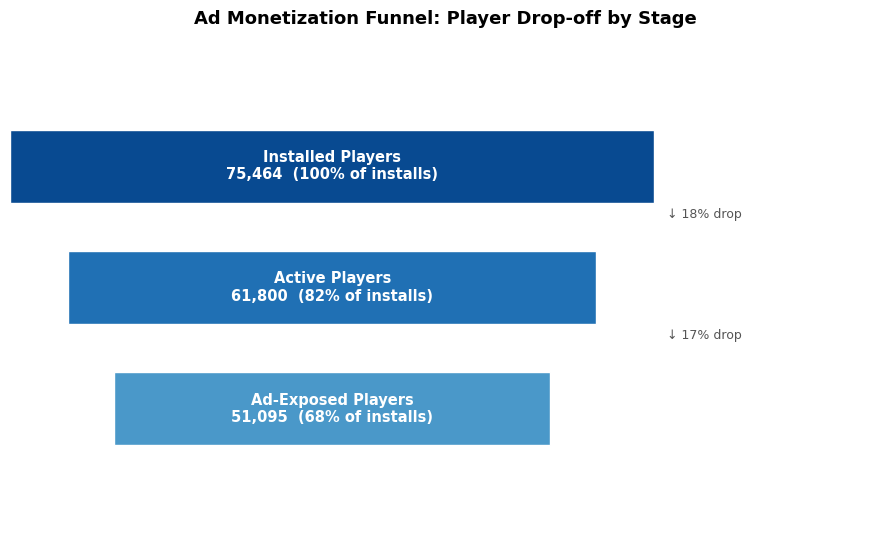

In [238]:
labels = list(stages.keys())
values = list(stages.values())
max_val = values[0]
 
fig, ax = plt.subplots(figsize=(9, 5.5))
 
bar_height = 0.6
y_positions = range(len(labels))[::-1]  # top to bottom
 
colors = plt.cm.Blues([0.9 - 0.15 * i for i in range(len(labels))])
 
for i, (label, value, y) in enumerate(zip(labels, values, y_positions)):
    width = value / max_val
    # center the bar to create the funnel taper effect
    left = (1 - width) / 2
    ax.barh(y, width, left=left, height=bar_height, color=colors[i], edgecolor="white")
 
    pct_of_total = value / max_val * 100
    # value + % label inside/at end of bar
    ax.text(0.5, y, f"{label}\n{value:,}  ({pct_of_total:.0f}% of installs)",
            ha="center", va="center", fontsize=10.5, color="white", fontweight="bold")
 
    # drop-off annotation between stages
    if i > 0:
        prev_value = values[i - 1]
        drop_pct = (1 - value / prev_value) * 100
        ax.text(1.02, y + bar_height / 2 + 0.3, f"↓ {drop_pct:.0f}% drop",
                ha="left", va="center", fontsize=9, color="#555555")
 
ax.set_xlim(0, 1.35)
ax.set_ylim(-1, len(labels))
ax.axis("off")
ax.set_title("Ad Monetization Funnel: Player Drop-off by Stage",
             fontsize=13, fontweight="bold", pad=15)
 
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/funnel_dropoff.png", dpi=200, bbox_inches="tight")
# print("Saved funnel_dropoff.png")
 

## 2. Network × Placement performance matrix
Here, I'll assign hyotheticsl netowrks and channels to make the analysis realistic

In [45]:
df.groupby(['network', 'ad_placement', 'event_type', 'event_name']).user_id.count().sort_values(ascending=False)

network   ad_placement  event_type     event_name
b98072a5  9e17b867      ad_impression  ad_reward     3332889
8ef7ca0d  6fc118c8      ad_impression  ad_reward     2826755
c2b68400  02674f0c      ad_impression  ad_reward     2417876
54b36581  e7146d79      ad_impression  ad_reward     2040132
4710c070  018933a5      ad_impression  ad_reward     1659910
ba78355e  6a75a998      ad_impression  ad_reward     1361893
29a106dd  2401f920      ad_impression  ad_reward     1184040
0f95c3e4  db2fa9e8      ad_impression  ad_reward     1084342
62865ca7  6fc118c8      ad_impression  ad_reward      653517
48dbfa82  27792d2d      ad_impression  ad_reward      652746
6fa365a1  05f3136b      ad_impression  ad_reward      353699
72ffa408  eb5f6d53      ad_impression  ad_reward      314784
4710c070  e1e6dcbc      ad_impression  ad_reward      127175
0f95c3e4  5c3d47b6      ad_impression  ad_reward      122017
54b36581  262e10fd      ad_impression  ad_reward      115607
6fa365a1  11abab9b      ad_impressi

In [46]:
# replace the network names
network_map = {
    'b98072a5': 'AppLovin',
    '8ef7ca0d': 'Unity Ads',
    'c2b68400': 'ironSource / LevelPlay',
    '54b36581': 'AdMob',
    '4710c070': 'Meta Audience Network',
    'ba78355e': 'Liftoff Monetize / Vungle',
    '29a106dd': 'Mintegral',
    '0f95c3e4': 'Pangle',
    '48dbfa82': 'Moloco',
    '62865ca7': 'Digital Turbine',
    '6fa365a1': 'Chartboost',
    '72ffa408': 'InMobi'
}

df['ad_network_name'] = df['network'].map(network_map)

In [47]:
# Develop eCPM and Revenue/User column in df
performance = (
    df.groupby(['ad_network_name', 'ad_placement']).agg(
        impressions = ('user_id', 'count'),
        unique_users = ('user_id', 'nunique'),
        revenue = ('revenue_usd', 'sum')
    ).assign(
        eCPM=lambda x: round(x['revenue'] / x['impressions'] * 1000, 2),
        revenue_per_user=lambda x: round(x['revenue'] / x['unique_users'], 4),
        pct_impressions = lambda x: round((x['impressions']/ x['impressions'].sum())*100.0, 2),
        pct_users = lambda x: round((x['unique_users']/ x['unique_users'].sum())*100.0, 2),
        pct_revenue = lambda x: round((x['revenue']/ x['revenue'].sum())*100.0, 2),
    ).sort_values('eCPM', ascending=False))
            
performance       

,,impressions,unique_users,revenue,eCPM,revenue_per_user,pct_impressions,pct_users,pct_revenue
ad_network_name,ad_placement,,,,,,,,
ironSource / LevelPlay,56d1d951,10885,328,306.671602,28.17,0.9350,0.06,0.11,0.41
Pangle,5c3d47b6,122017,4099,1970.100996,16.15,0.4806,0.66,1.34,2.62
Chartboost,11abab9b,100180,4473,1436.603109,14.34,0.3212,0.54,1.47,1.91
Meta Audience Network,e1e6dcbc,127175,4427,1778.516021,13.98,0.4017,0.68,1.45,2.36
Unity Ads,6fc118c8,2826755,45600,31467.960694,11.13,0.6901,15.21,14.94,41.81
Moloco,00216aa2,54540,2275,598.965250,10.98,0.2633,0.29,0.75,0.80
AppLovin,2b2982d0,56605,2038,485.243088,8.57,0.2381,0.30,0.67,0.64
AdMob,262e10fd,115607,1720,843.198578,7.29,0.4902,0.62,0.56,1.12
Liftoff Monetize / Vungle,64c99e5c,95693,2912,677.103903,7.08,0.2325,0.51,0.95,0.90


In [139]:
df.groupby(['ad_network_name', 'ad_placement', 'event_type', 'event_name']).user_id.count()

ad_network_name            ad_placement  event_type     event_name
AdMob                      262e10fd      ad_impression  ad_reward      115607
                           e7146d79      ad_impression  ad_reward     2040132
AppLovin                   2b2982d0      ad_impression  ad_reward       56605
                           9e17b867      ad_impression  ad_reward     3332889
Chartboost                 05f3136b      ad_impression  ad_reward      353699
                           11abab9b      ad_impression  ad_reward      100180
Digital Turbine            6fc118c8      ad_impression  ad_reward      653517
InMobi                     eb5f6d53      ad_impression  ad_reward      314784
Liftoff Monetize / Vungle  64c99e5c      ad_impression  ad_reward       95693
                           6a75a998      ad_impression  ad_reward     1361893
Meta Audience Network      018933a5      ad_impression  ad_reward     1659910
                           e1e6dcbc      ad_impression  ad_reward      1271

## 2'. Country and platform

In [171]:
df_ad_rev = df[df['event_type'] == 'ad_impression']

df_ad_rev.groupby(['platform', 'country_tier']).user_id.count().sort_values(ascending=False)

platform  country_tier
android   RU              3666192
          VN              2809777
          UA              2385808
          OTHER           2171205
          TR              1185767
          UZ              1011147
          IR               824041
          DE               591928
          US               415625
          PL               399401
          IN               382648
          NL               343901
ios       RU               306348
          OTHER            269302
android   UK               217080
          FR               204773
          IT               180700
ios       US               175951
android   ES               131070
          CZ                99050
ios       NL                97824
          DE                96566
android   BY                92788
          ID                60290
          BR                55037
          JP                50995
ios       UK                49216
          FR                42920
android   KZ             

In [173]:
# Develop eCPM and Revenue/User column in df
performance_country_pl = (
    df_ad_rev.groupby(['platform', 'country_tier']).agg(
        impressions = ('user_id', 'count'),
        unique_users = ('user_id', 'nunique'),
        revenue = ('revenue_usd', 'sum')
    ).assign(
        eCPM=lambda x: round(x['revenue'] / x['impressions'] * 1000, 2),
        revenue_per_user=lambda x: round(x['revenue'] / x['unique_users'], 4),
        pct_impressions = lambda x: round((x['impressions']/ x['impressions'].sum())*100.0, 2),
        pct_users = lambda x: round((x['unique_users']/ x['unique_users'].sum())*100.0, 2),
        pct_revenue = lambda x: round((x['revenue']/ x['revenue'].sum())*100.0, 2),
    ).sort_values('eCPM', ascending=False))
performance_country_pl    

impressions  unique_users       revenue   eCPM  \
platform country_tier                                                   
ios      KR                   5019            90    169.414259  33.75   
         US                 175951          2270   4730.030305  26.88   
         JP                  34912           474    858.912873  24.60   
         TR                  21021           313    516.128954  24.55   
         UK                  49216           579   1128.979316  22.94   
android  KR                  34252           417    764.728335  22.33   
ios      FR                  42920           487    877.818660  20.45   
         ES                  12445           163    235.164710  18.90   
         DE                  96566           874   1767.835494  18.31   
         OTHER              269302          2658   4564.217716  16.95   
         RU                 306348          3241   4488.876301  14.65   
         NL                  97824           602   1342.112032  13.72   
         KZ                   2763            91     36.820260  13.33   
         BR                   3802           123     48.525193  12.76   
         UA                  22817           268    278.396085  12.20   
         IT                  20261           209    246.041971  12.14   
         CZ                  13778            78    157.689277  11.45   
android  US                 415625          2521   4503.704689  10.84   
         JP                  50995           315    526.375213  10.32   
ios      IR                   5594            37     55.081319   9.85   
         UZ                   1133            58     10.086876   8.90   
         PL                  25063           151    221.921342   8.85   
android  UK                 217080           819   1709.914054   7.88   
ios      ID                   5370            32     41.087688   7.65   
android  DE                 591928          2064   3630.090159   6.13   
ios      BY                    435             8      2.550623   5.86   
android  FR                 204773           929   1164.330392   5.69   
         CZ                  99050           278    491.431632   4.96   
         NL                 343901           928   1662.757830   4.83   
ios      VN                  18918           246     89.679569   4.74   
         IN                   4731            96     20.653193   4.37   
android  RU                3666192         18324  15198.077623   4.15   
         IT                 180700           717    713.453324   3.95   
         OTHER             2171205          8528   8564.375812   3.94   
         PL                 399401          1272   1412.138574   3.54   
         BR                  55037           656    191.303484   3.48   
         ES                 131070           568    435.217431   3.32   
         ID                  60290           615    164.600018   2.73   
         TR                1185767          4345   3194.452404   2.69   
         BY                  92788           437    247.273179   2.66   
         KZ                  41002           345     88.920238   2.17   
         UA                2385808          5228   4374.892226   1.83   
         UZ                1011147          2786    994.954549   0.98   
         VN                2809777          5149   2652.963656   0.94   
         IN                 382648          2049    318.077906   0.83   
         IR                 824041          2571    380.231845   0.46   

                       revenue_per_user  pct_impressions  pct_users  \
platform country_tier                                                 
ios      KR                      1.8824             0.03       0.12   
         US                      2.0837             0.95       3.03   
         JP                      1.8121             0.19       0.63   
         TR                      1.6490             0.11       0.42   
         UK                      1.9499             0.26       0.77   
android  KR          

## 3. Volume vs. efficiency scatterplot

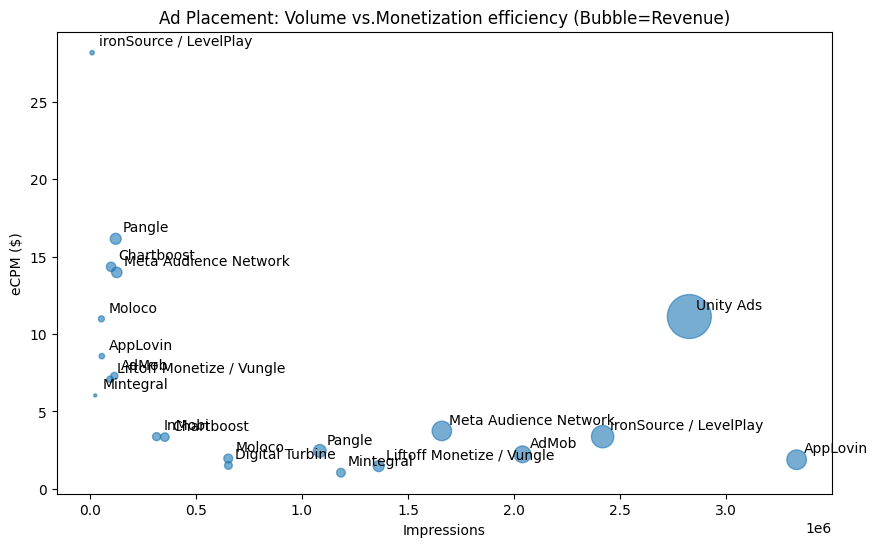

In [240]:
plt.figure(figsize=(10, 6))
plt.scatter(
    performance['impressions'],
    performance['eCPM'],
    # marker size = s
    s=performance['revenue'] / performance['revenue'].max() * 1000,
    alpha=0.6)

for (network, placement), row in performance.iterrows():
    plt.annotate(
        f'{network}',
        # f'{network} \n{placement}',
        (row['impressions'], row['eCPM']),
        xytext=(5, 5),
        textcoords='offset points'
    )
    
plt.xlabel('Impressions')
plt.ylabel('eCPM ($)')
plt.title('Ad Placement: Volume vs.Monetization efficiency (Bubble=Revenue)')

plt.show()

### Interpretation of the results
|#| High eCPM |	Low eCPM |
|---|---|---|
| High impressions |🟢 Scale winners — high volume + efficient	| 🟡 Optimization opportunities — lots of volume but inefficient
| Low impressions |	🔵 Potential to scale — efficient but underutilized| 	⚪ Low priority

## 4. eCPM by player lifecycle

In [141]:
# slice df by ad revenue no iap
df_ad_rev = df[df['event_type'] == 'ad_impression']

day_ecpm = df_ad_rev.groupby(['install_day']).agg(
    impressions = ('user_id', 'count'),
    unique_users = ('user_id', 'nunique'),
    revenue = ('revenue_usd', 'sum')).assign(
        eCPM=lambda x: round(x['revenue'] / x['impressions'] * 1000, 2)
    ).reset_index()

In [142]:
day_ecpm.head()

,install_day,impressions,unique_users,revenue,eCPM
0,0,2017074,11063,11937.722573,5.92
1,1,538831,2518,2352.378982,4.37
2,2,540614,2201,2406.347478,4.45
3,3,497445,2121,2270.390048,4.56
4,4,514305,2087,1911.842213,3.72


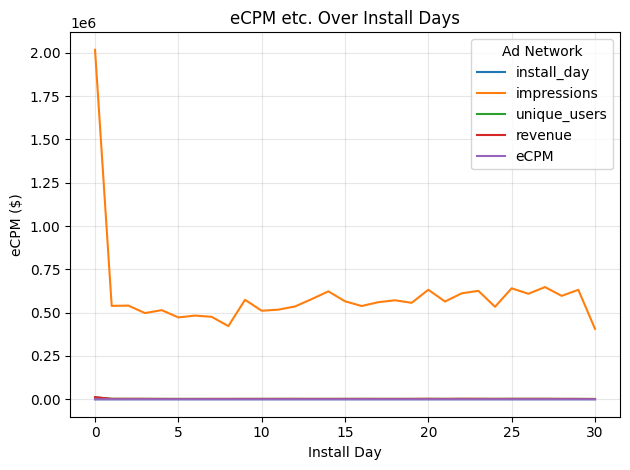

In [187]:
day_ecpm.plot()
plt.xlabel('Install Day')
plt.ylabel('eCPM ($)')
plt.title('eCPM etc. Over Install Days')
plt.legend(title='Ad Network')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_1856/3621963368.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Ad Network')


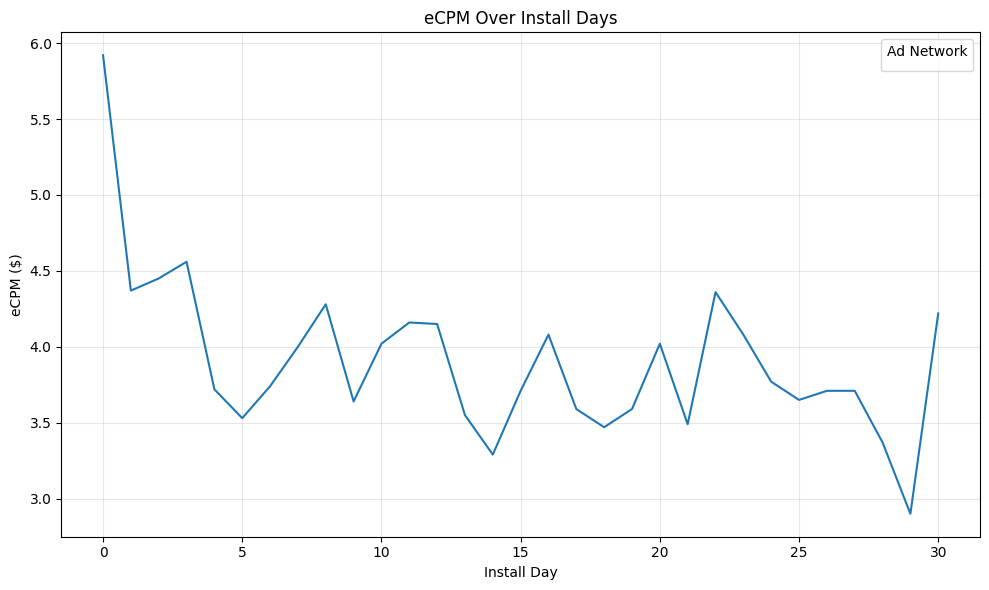

In [185]:
plt.figure(figsize=(10, 6))

plt.plot(day_ecpm['install_day'], day_ecpm['eCPM'])
plt.xlabel('Install Day')
plt.ylabel('eCPM ($)')
plt.title('eCPM Over Install Days')
plt.legend(title='Ad Network')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [177]:
# see by hours
# slice df by ad revenue no iap
df_ad_rev = df[df['event_type'] == 'ad_impression']

hr_ecpm = df_ad_rev.groupby(['event_hour']).agg(
    impressions = ('user_id', 'count'),
    unique_users = ('user_id', 'nunique'),
    revenue = ('revenue_usd', 'sum')).assign(
        eCPM=lambda x: round(x['revenue'] / x['impressions'] * 1000, 2)
    ).reset_index()

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_1856/1987796775.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Ad Network')


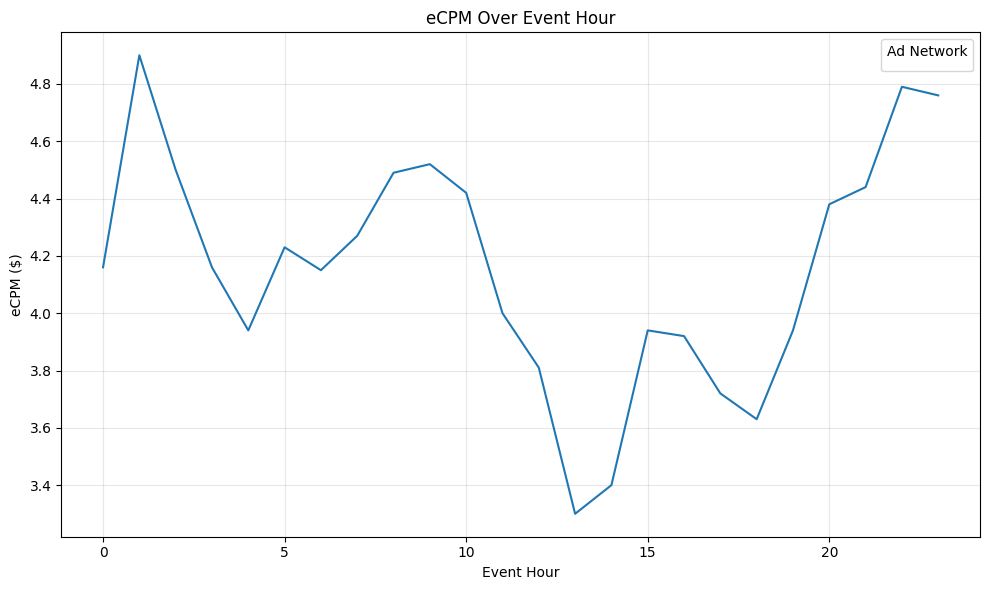

In [189]:
plt.figure(figsize=(10, 6))

plt.plot(hr_ecpm['event_hour'], hr_ecpm['eCPM'])
plt.xlabel('Event Hour')
plt.ylabel('eCPM ($)')
plt.title('eCPM Over Event Hour')
plt.legend(title='Ad Network')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [175]:
# Breakdown by network/ad_placement
df_ecpm_network = df_ad_rev.groupby(['install_day', 'ad_network_name']).agg(
    impressions = ('user_id', 'count'),
    unique_users = ('user_id', 'nunique'),
    revenue = ('revenue_usd', 'sum')).assign(
        eCPM=lambda x: round(x['revenue'] / x['impressions'] * 1000, 2)
    ).reset_index()
df_ecpm_network.head()

,install_day,ad_network_name,impressions,unique_users,revenue,eCPM
0,0,AdMob,284640,3790,1071.618127,3.76
1,0,AppLovin,263880,3938,879.187470,3.33
2,0,Chartboost,64283,4190,455.706186,7.09
3,0,Digital Turbine,56790,2565,153.365700,2.70
4,0,InMobi,24133,1050,117.554692,4.87


In [165]:
ecpm_by_network.head()

ad_network_name,AdMob,AppLovin,Chartboost,Digital Turbine,InMobi,Liftoff Monetize / Vungle,Meta Audience Network,Mintegral,Moloco,Pangle,Unity Ads,ironSource / LevelPlay
install_day,,,,,,,,,,,,
0,3.76,3.33,7.09,2.70,4.87,2.94,5.97,2.00,4.42,5.23,11.50,5.49
1,3.06,1.89,7.15,1.52,4.83,1.58,5.04,1.15,2.92,4.42,10.81,3.68
2,3.23,1.86,7.32,1.48,4.25,1.71,4.86,1.05,2.54,4.21,13.13,3.30
3,3.15,2.82,6.53,1.71,6.00,2.21,4.73,0.99,3.28,4.99,12.23,3.37
4,2.76,2.24,4.79,1.23,3.61,2.04,4.16,0.88,2.24,3.70,9.99,3.36


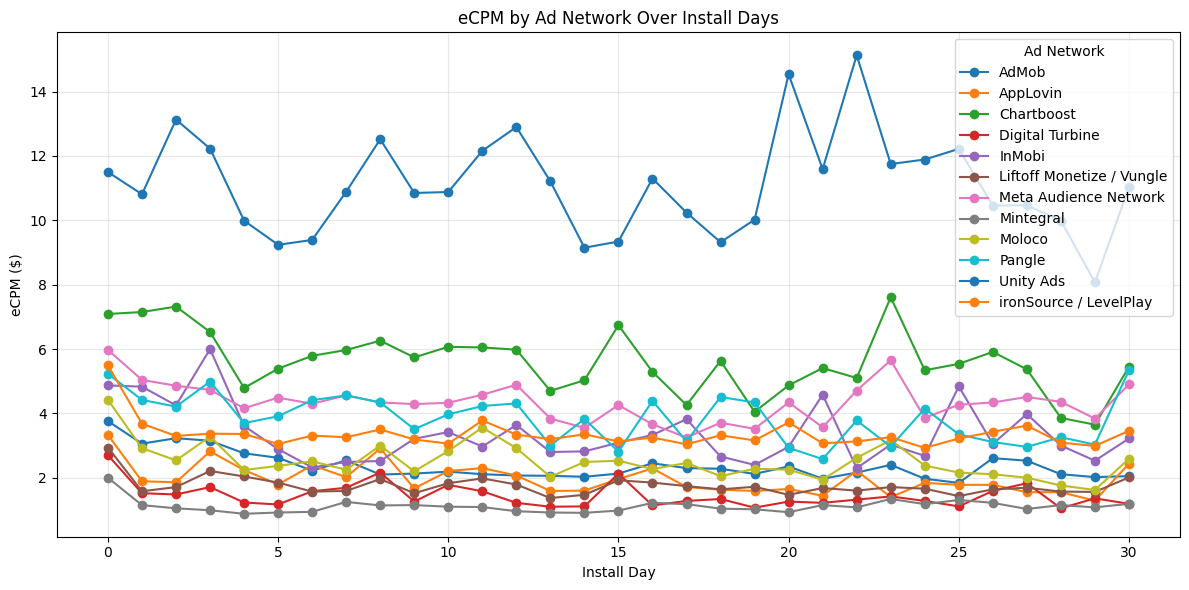

In [161]:

ecpm_by_network = df_ecpm_network.pivot(
    index='install_day',
    columns='ad_network_name',
    values='eCPM'
)

plt.figure(figsize=(12, 6))

for network in ecpm_by_network.columns:
    plt.plot(
        ecpm_by_network.index,
        ecpm_by_network[network],
        marker='o',
        label=network
    )

plt.xlabel('Install Day')
plt.ylabel('eCPM ($)')
plt.title('eCPM by Ad Network Over Install Days')
plt.legend(title='Ad Network')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [254]:
day_ecpm

,install_day,impressions,unique_users,revenue,eCPM
0,0,2017074,11063,11937.722573,5.92
1,1,538831,2518,2352.378982,4.37
2,2,540614,2201,2406.347478,4.45
3,3,497445,2121,2270.390048,4.56
4,4,514305,2087,1911.842213,3.72
5,5,472393,1965,1667.325547,3.53
6,6,482846,1957,1804.212922,3.74
7,7,475834,1907,1905.100690,4.00
8,8,422312,1927,1809.124761,4.28
9,9,573940,2086,2087.966494,3.64
